In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from joblib import load
from tqdm import tqdm
import warnings

from sklearn.metrics import classification_report
warnings.filterwarnings("ignore")
import glob
import os
from collections import OrderedDict
from src.layers.classifiers import TokenClassifier, MixedClassifier

import h5py
import sys

import numpy as np
import matplotlib.pyplot as plt 
from matplotlib import cm


In [2]:
dict = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

In [3]:

path = '/home/mdelafuente/'#sys.argv[2]

 
abs_path = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC_MD/MM_BASELINE_/'
path_args = glob.glob(f"{abs_path}*args*")[0]
print(path_args)
import yaml
with open(path_args, 'r') as file:
    args = yaml.safe_load(file)

/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC_MD/MM_BASELINE_/args.yaml


In [4]:
print('Initializing models') 
from src.layers.selfsupervised.multimodal import ATAT
model = ATAT(**args) 


print('Loading checkpoints')
checkpoint_path_clip = glob.glob(
    f"{abs_path}*my_best_checkpoint*"
) 
print(checkpoint_path_clip[-1])
checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
od_atat = OrderedDict() 

for key in checkpoint_clip["state_dict"].keys(): 
        print(key)
         
         
        od_atat[key.replace("atat.", "")] = checkpoint_clip["state_dict"][key]

model.load_state_dict(od_atat,strict=True)

Initializing models
{'embedding_size': 128, 'embedding_size_sub': 256, 'num_heads': 4, 'num_encoders': 3, 'encoder_type': 'Linear', 'length_size': 6, 'list_time_to_eval': None}
Loading checkpoints
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC_MD/MM_BASELINE_/my_best_checkpoint-step=2133.ckpt
atat.LC.m_token
atat.LC.time_encoder.time_encoders.0.alpha_sin
atat.LC.time_encoder.time_encoders.0.alpha_cos
atat.LC.time_encoder.time_encoders.0.beta_sin
atat.LC.time_encoder.time_encoders.0.beta_cos
atat.LC.time_encoder.time_encoders.0.ar
atat.LC.time_encoder.time_encoders.0.linear_proj.0.weight
atat.LC.time_encoder.time_encoders.0.linear_proj.0.bias
atat.LC.time_encoder.time_encoders.1.alpha_sin
atat.LC.time_encoder.time_encoders.1.alpha_cos
atat.LC.time_encoder.time_encoders.1.beta_sin
atat.LC.time_encoder.time_encoders.1.beta_cos
atat.LC.time_encoder.time_encoders.1.ar
atat.LC.time_encoder.time_encoders.1.linear_proj.0.weight
atat.LC.time_encoder

<All keys matched successfully>

In [5]:
seed = 0
from src.data.modules.LitData  import LitData



args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
args['general']['use_sampler'] = False
args['general']['batch_size'] = 128

pl_datal = LitData(**args['general'])
dataloader = pl_datal.val_dataloader() 
    

using set validation total of idx : 40698,                 use_lightcurves True, use_metadata True, use_features False,                     use MTA False
list_time_to_eval:  [16, 32, 64, 128, 256, 512, 1024, 2048]
using set_Type validation
NOT USING SAMPLER


In [7]:
target = None
preds_out = None

model.eval().to(device = 'cuda:2')  

for b1 in tqdm(dataloader):

    #print(b1.keys())
    b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}

    lc_emb,tab_emb,mix_emb = model(**b1)  
   
    t = b1['labels']


    preds_out = (
        np.concatenate([preds_out, torch.argmax(mix_emb, axis=1).cpu().numpy()])
        if preds_out is not None
        else torch.argmax(mix_emb, axis=1).cpu().detach().numpy()
    )

    target = (
        np.concatenate([target, t.cpu().detach().numpy()])
        if target is not None
        else t.cpu().numpy()
    )

  0%|          | 0/318 [00:00<?, ?it/s]

100%|██████████| 318/318 [00:18<00:00, 17.23it/s]


In [8]:
results = preds_out
classification = classification_report(target, results, target_names=list(dict.keys()),digits = 4)
print(classification)

                precision    recall  f1-score   support

           AGN     0.7791    0.7819    0.7805      3288
           QSO     0.8360    0.8296    0.8328      3428
            EA     0.7089    0.7617    0.7343      3500
           YSO     0.7837    0.7687    0.7761      2715
          SNIa     0.6917    0.4722    0.5613      1639
       CV/Nova     0.6828    0.7081    0.6952      1617
          RRLc     0.7021    0.6580    0.6794      3439
         RSCVn     0.6813    0.7240    0.7020      2522
        Blazar     0.7373    0.7243    0.7308      1364
          SNII     0.3959    0.3392    0.3653       802
         EB/EW     0.7034    0.6380    0.6691      3635
           LPV     0.9422    0.8982    0.9196      3319
           CEP     0.7789    0.6872    0.7302      2871
         RRLab     0.7145    0.6752    0.6943      3507
Periodic-Other     0.3199    0.5040    0.3914       742
          DSCT     0.4612    0.5112    0.4849      1604
         SNIbc     0.1236    0.1438    0.1329  

AGN {'precision': 0.7790909090909091, 'recall': 0.781934306569343, 'f1-score': 0.7805100182149363, 'support': 3288.0}
QSO {'precision': 0.8359788359788359, 'recall': 0.8296382730455076, 'f1-score': 0.832796486090776, 'support': 3428.0}
EA {'precision': 0.7088540281839936, 'recall': 0.7617142857142857, 'f1-score': 0.7343341137584355, 'support': 3500.0}
YSO {'precision': 0.7837025910627112, 'recall': 0.7686924493554328, 'f1-score': 0.7761249535143175, 'support': 2715.0}
SNIa {'precision': 0.6916890080428955, 'recall': 0.4722391702257474, 'f1-score': 0.5612762871646121, 'support': 1639.0}
CV/Nova {'precision': 0.6827668455575432, 'recall': 0.7081014223871367, 'f1-score': 0.6952034001214329, 'support': 1617.0}
RRLc {'precision': 0.7021408625504189, 'recall': 0.6580401279441698, 'f1-score': 0.6793755628940258, 'support': 3439.0}
RSCVn {'precision': 0.6813432835820895, 'recall': 0.7240285487708168, 'f1-score': 0.7020376778162245, 'support': 2522.0}
Blazar {'precision': 0.7373134328358208, 'r

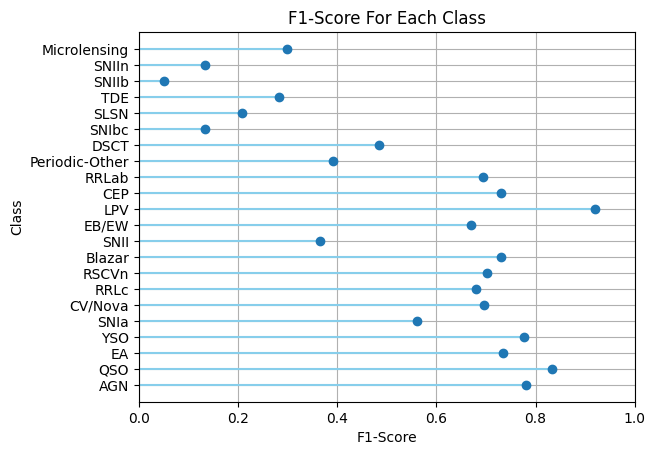

In [9]:
data_dict =  classification_report(target, results, target_names=list(dict.keys()),digits = 4, output_dict=True)
classes = data_dict.keys()
f1 = []
for key,value in data_dict.items():
    if key in dict.keys():
        print(key,value)
        f1.append(value['f1-score'])
print(f1)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
 
# Create a dataframe
df = pd.DataFrame({'group':dict.keys(), 'values':f1 })
 
# Reorder it based on the values
ordered_df = df#.sort_values(by='values')
my_range=range(1,len(df.index)+1)
 
# The horizontal plot is made using the hline function
plt.hlines(y=my_range, xmin=0, xmax=ordered_df['values'], color='skyblue')
plt.plot(ordered_df['values'].values, my_range, "o")
 
# Add titles and axis names
plt.yticks(my_range, ordered_df['group'])
plt.title("F1-Score For Each Class", loc='center')

plt.xlabel('F1-Score')
plt.ylabel('Class')
plt.xlim(0,1)

plt.grid('on')
# Show the plot
plt.show()

In [10]:
transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}
stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}
periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}

In [11]:
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in data_dict.items():
    #print(class_key)
    if class_key in dict.keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))

print('per',np.mean(per_f1))

group eval:
trans 0.25405071007186947
stoch 0.7630808177421388
per 0.6672576410017572


Normalized confusion matrix


<Axes: title={'center': ' FClassifier Results [TEST] \n\n  PRECISION : 0.531  RECALL : 0.587  F1-SCORE : 0.539  SUPPORT : 40698.000 '}, xlabel='Predicted label', ylabel='True label'>

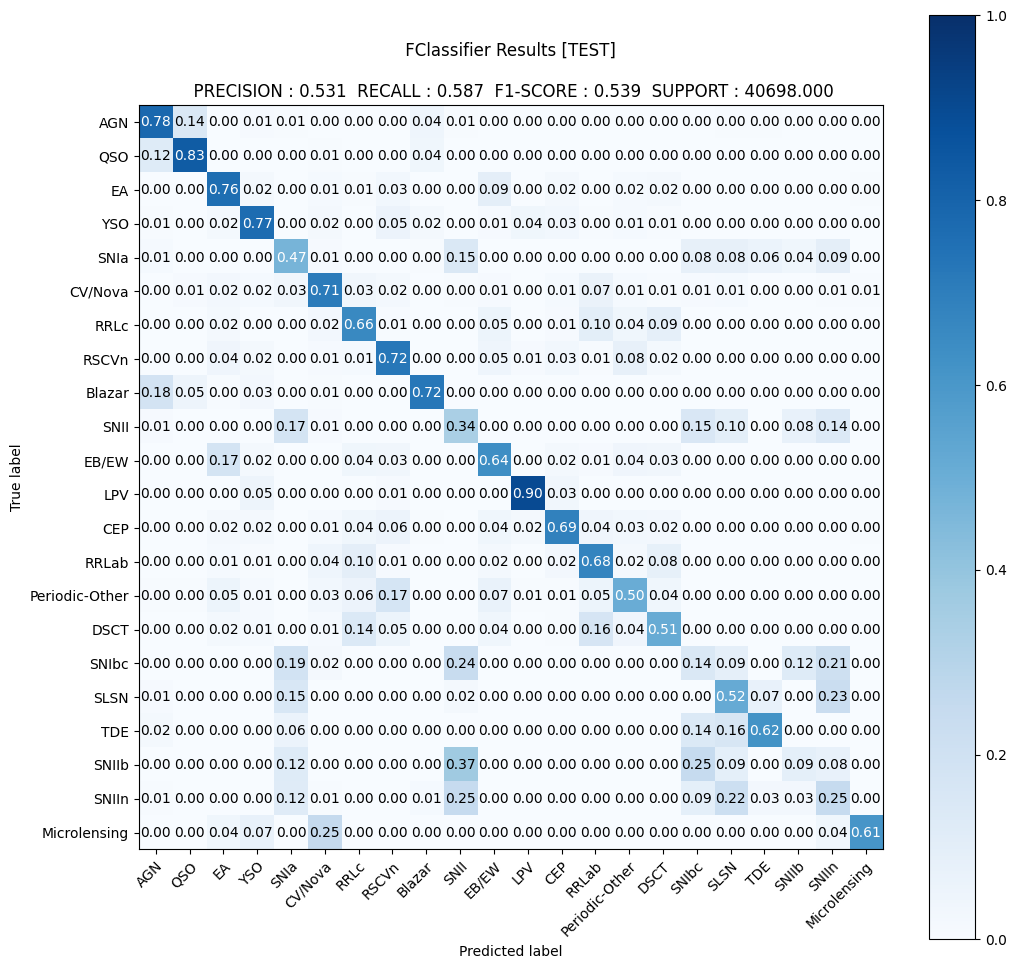

In [12]:
import matplotlib.pyplot as plt
from src.utils.plottinglib import elasticc_confusion_matrix
out_metrics_balto = classification_report(
    target, results, target_names=list(dict.keys()), output_dict=True
)["macro avg"]

template_balto = ""

for key in out_metrics_balto.keys():
    template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
fig, axes = plt.subplots(1, 1, figsize=(12, 12))
elasticc_confusion_matrix(
    y_true=np.array(target).astype(int),
    y_pred=np.array(results).astype(int),
    classes= np.array(list(dict.keys())),
    ax=axes,
    normalize=True,
    title=f" FClassifier Results [TEST] \n\n {template_balto}",
)